# Разведочный анализ данных (EDA) химических соединений

В данном ноутбуке проводится первичный анализ данных 1001 химических соединений с целью изучения распределения целевых переменных (`IC50`, `CC50`, `SI`), выявления закономерностей и подготовки данных для последующего построения прогнозных моделей машинного обучения.

## 1. Загрузка и просмотр данных

In [33]:
# 1 Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import sys
import os

# Добавляем корень проекта в путь
sys.path.append(os.path.dirname(os.getcwd()))

from src import load_raw_data

# Загружаем данные
df = load_raw_data()

In [35]:
#df = pd.read_excel('../data/raw/Данные_для_курсовои__Классическое_МО.xlsx')
df.shape

(1001, 214)

In [36]:
df

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,996,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,...,0,0,0,0,0,0,0,0,0,0
997,997,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,...,0,0,0,0,0,0,0,0,0,0
998,998,30.999883,33.999458,1.096761,13.991690,13.991690,0.026535,-0.650790,0.284923,41.973684,...,1,0,0,0,0,0,0,0,0,0
999,999,31.998959,32.999644,1.031272,13.830180,13.830180,0.146522,-1.408652,0.381559,39.000000,...,0,0,0,0,0,0,0,0,0,0


## 2. Анализ структуры данных

In [37]:
print(df.dtypes)

Unnamed: 0             int64
IC50, mM             float64
CC50, mM             float64
SI                   float64
MaxAbsEStateIndex    float64
                      ...   
fr_thiazole            int64
fr_thiocyan            int64
fr_thiophene           int64
fr_unbrch_alkane       int64
fr_urea                int64
Length: 214, dtype: object


In [38]:
# Создаём DataFrame с информацией о типах данных всех 214 колонок
dtype_info = pd.DataFrame({
    'Столбец': df.columns,
    'Тип данных': df.dtypes.values
})

# Добавляем информацию о количестве уникальных значений
dtype_info['Уникальных'] = [df[col].nunique() for col in df.columns]

print(dtype_info.to_string(index=False))

                 Столбец Тип данных  Уникальных
              Unnamed: 0      int64        1001
                IC50, mM    float64         953
                CC50, mM    float64         888
                      SI    float64         768
       MaxAbsEStateIndex    float64         793
          MaxEStateIndex    float64         793
       MinAbsEStateIndex    float64         790
          MinEStateIndex    float64         796
                     qed    float64         758
                     SPS    float64         597
                   MolWt    float64         712
          HeavyAtomMolWt    float64         605
              ExactMolWt    float64         693
     NumValenceElectrons      int64         112
     NumRadicalElectrons      int64           1
        MaxPartialCharge    float64         722
        MinPartialCharge    float64         654
     MaxAbsPartialCharge    float64         662
     MinAbsPartialCharge    float64         719
        FpDensityMorgan1    float64     

### Краткое заключение о структуре данных

Датасет содержит 1001 запись и 214 числовых признаков.

- **Целевые переменные** (`IC50`, `CC50`, `SI`) имеют высокую вариативность (768–953 уникальных значений), что указывает на разнообразие соединений по активности и токсичности.
- Столбец `Unnamed: 0` — идентификатор, подлежит удалению.


## 3. Проверка пропусков

In [39]:
# выведем колонки в которых еть пропуски
cols_with_nulls = df.columns[df.isnull().sum() > 0].tolist()
cols_with_nulls

['MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW']

In [40]:
# Таблица с количеством пропусков
nulls_df = pd.DataFrame({
    'Столбец': cols_with_nulls,
    'Пропусков': df[cols_with_nulls].isnull().sum().values
})

nulls_df

,Столбец,Пропусков
0,MaxPartialCharge,3
1,MinPartialCharge,3
2,MaxAbsPartialCharge,3
3,MinAbsPartialCharge,3
4,BCUT2D_MWHI,3
5,BCUT2D_MWLOW,3
6,BCUT2D_CHGHI,3
7,BCUT2D_CHGLO,3
8,BCUT2D_LOGPHI,3
9,BCUT2D_LOGPLOW,3


Количество пропусков во всех 12 столбцах одинаковое (по 3 пропуска). Предполагаем, что это одни и те же 3 строки. Проверим эту гипотезу.

In [41]:
# Находим строки, где есть хотя бы один пропуск
rows_with_nulls = df[df.isnull().any(axis=1)]
rows_with_nulls[cols_with_nulls]

,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW
78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



В ходе первичной проверки выявлено **12 столбцов** с пропусками. При детальном анализе установлено, что все пропуски находятся **в одних и тех же 3 строках**.

**Решение -** строки с пропусками удаляются, так как удаление 3 строк (0.3% данных) не повлияет на общую статистику и качество моделей.


## 4. Анализ целевых переменных

In [42]:
# обозначим целевые переменные
target_cols = ['IC50, mM', 'CC50, mM', 'SI']

In [43]:
df[target_cols].describe()

,"IC50, mM","CC50, mM",SI
count,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823
std,402.169734,642.867508,684.482739
min,0.003517,0.700808,0.011489
25%,12.515396,99.999036,1.433333
50%,46.585183,411.039342,3.846154
75%,224.975928,894.089176,16.566667
max,4128.529377,4538.976189,15620.600000



#### Анализ трёх целевых переменных

**IC50** (противовирусная активность) имеет сильный скос: среднее (222.81 мМ) в 4.8 раз превышает медиану (46.59 мМ). Три четверти соединений имеют IC50 ниже 225 мМ, но отдельные вещества достигают 4128 мМ (крайне неактивные) или опускаются до 0.004 мМ (высокоактивные).

**CC50** (цитотоксичность) распределена наиболее равномерно: среднее (589.11 мМ) превышает медиану (411.04 мМ) всего в 1.4 раза, 75% соединений имеют CC50 < 894 мМ.

**SI** (индекс селективности) — самая проблемная переменная: среднее (72.51) в **18.9 раз** превышает медиану (3.85), а 75% соединений имеют SI < 16.57, что говорит о том, что большинство соединений небезопасны или малоэффективны. Единичные соединения с экстремально высоким SI (максимум 15620.60) кардинально искажают среднее значение.



#### Дополнительные метрики

In [44]:
# Собираем данные
metrics_data = []

for col in target_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    cv = df[col].std() / df[col].mean()
    zeros = (df[col] <= 0).sum()
    missing = df[col].isnull().sum()


    metrics_data.append({
        'Переменная': col,
        'Skewness': f"{skew:.4f}",
        'Kurtosis': f"{kurt:.4f}",
        'CV': f"{cv:.4f}",
        'Значений ≤ 0': zeros,
        'Пропуски': missing
    })

# Создаём и выводим таблицу
metrics_df = pd.DataFrame(metrics_data)

print(metrics_df.to_string(index=False))

Переменная Skewness Kurtosis     CV  Значений ≤ 0  Пропуски
  IC50, mM   3.6749  22.4503 1.8050             0         0
  CC50, mM   1.9733   5.6794 1.0913             0         0
        SI  18.0132 361.4167 9.4400             0         0


### Предварительный вывод по целевым переменным

На основе описательных статистик и дополнительных метрик можно сделать следующие предварительные выводы:

**1. Все три переменные имеют правосторонний скос (skewness > 0):**
- **IC50** (skewness = 3.67) — сильный скос, есть очень неактивные соединения
- **CC50** (skewness = 1.97) — умеренный скос, есть высокотоксичные соединения
- **SI** (skewness = 18.01) — критический скос, единичные соединения с экстремально высоким SI

**2. Характер хвостов (kurtosis):**
- **IC50** (kurtosis = 22.45) — очень тяжёлые хвосты, много выбросов
- **CC50** (kurtosis = 5.68) — тяжёлые хвосты, есть выбросы
- **SI** (kurtosis = 361.42) — экстремально тяжёлые хвосты, единичные сверх-выбросы

**3. Вариативность (CV):**
- **IC50** (CV = 1.81) — высокая вариативность
- **CC50** (CV = 1.09) — высокая вариативность
- **SI** (CV = 9.44) — колоссальная вариативность

**4. Качество данных:**
- Нулевых и отрицательных значений нет — данные физически корректны
- Пропусков нет — данные полные

**Общий вывод на данном этапе:**
Все три переменные имеют выраженный правосторонний скос и требуют логарифмической трансформации для регрессионных задач. Особенно критично это для SI, где распределение наиболее искажено. Выбросы не являются ошибками — это реальные соединения с экстремальными свойствами.

 Дальнейший анализ с использованием гистограмм и boxplot-диаграмм позволит визуально оценить характер распределений и принять окончательное решение по обработке данных.



### Гистограммы распределений


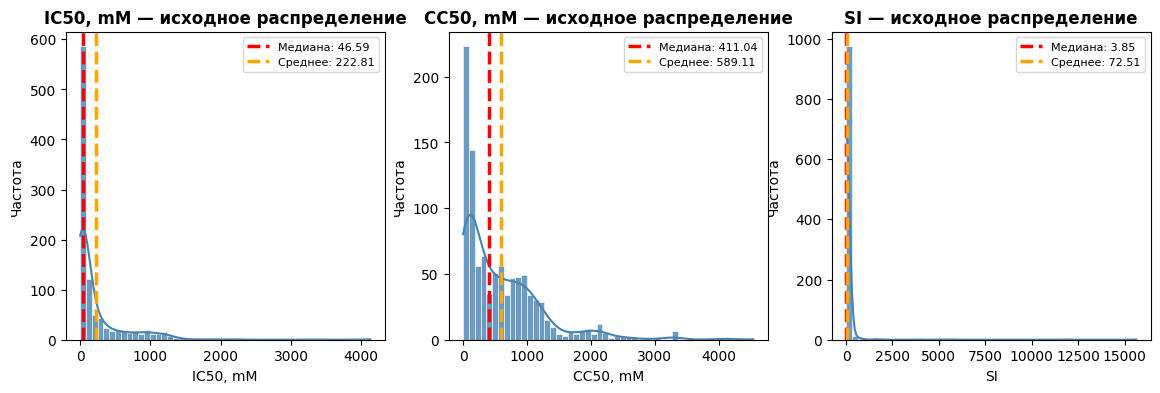

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(target_cols):
    # исходные значения
    ax1 = axes[i]
    sns.histplot(df[col], bins=50, kde=True, ax=ax1, color='steelblue', edgecolor='white', alpha=0.8)

    # Линии медианы и среднего
    median_val = df[col].median()
    mean_val = df[col].mean()
    ax1.axvline(median_val, color='red', linestyle='--', linewidth=2.5, label=f'Медиана: {median_val:.2f}')
    ax1.axvline(mean_val, color='orange', linestyle='--', linewidth=2.5, label=f'Среднее: {mean_val:.2f}')

    ax1.set_title(f'{col} — исходное распределение', fontsize=12, fontweight='bold')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Частота')
    ax1.legend(fontsize=8)

**Гистограммы подтверждают ранее сделанные выводы:**

Все три переменные имеют правосторонний скос, наиболее выраженный у **IC50 и SI**. Расхождение между средним и медианой визуально подтверждает влияние выбросов.

Данные требуют логарифмической трансформации.

### Анализ выбросов

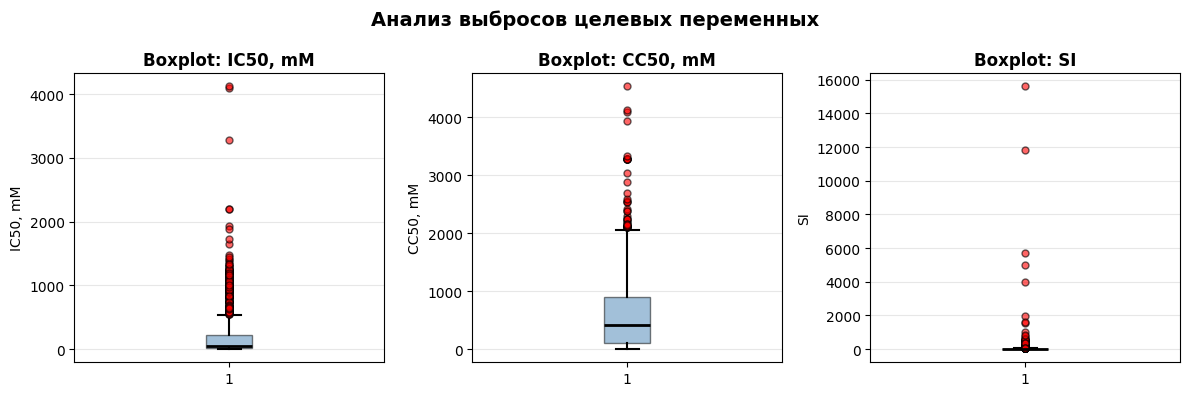

In [46]:
# 1. Boxplot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(target_cols):
    ax = axes[i]

    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5, 'alpha': 0.6},
                    medianprops={'color': 'black', 'linewidth': 2},
                    whiskerprops={'linewidth': 1.5}, capprops={'linewidth': 1.5})

    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.5)

    ax.set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Анализ выбросов целевых переменных', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
# 2. IQR-анализ

summary_data = []

for col in target_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_15 = Q3 + 1.5 * IQR
    upper_30 = Q3 + 3.0 * IQR

    n_15 = (df[col] > upper_15).sum()
    n_30 = (df[col] > upper_30).sum()

    summary_data.append({
        'Переменная': col,
        'IQR': IQR,
        'Граница 1.5×IQR': upper_15,
        'Выбросов 1.5×IQR': f"{n_15} ({n_15/len(df)*100:.1f}%)",
        'Граница 3.0×IQR': upper_30,
        'Выбросов 3.0×IQR': f"{n_30} ({n_30/len(df)*100:.1f}%)",
        'Максимум': df[col].max()
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

Переменная        IQR  Граница 1.5×IQR Выбросов 1.5×IQR  Граница 3.0×IQR Выбросов 3.0×IQR     Максимум
  IC50, mM 212.460532       543.666725      147 (14.7%)       862.357523        89 (8.9%)  4128.529377
  CC50, mM 794.090141      2085.224388        39 (3.9%)      3276.359599        11 (1.1%)  4538.976189
        SI  15.133333        39.266667      125 (12.5%)        61.966667        87 (8.7%) 15620.600000


### Вывод по анализу выбросов


**Все выбросы находятся в верхнем хвосте распределения** — значений ниже нижней границы нет. Это означает, что экстремальные значения — это всегда "очень большие" показатели, а не "очень маленькие".

- **IC50:** 14.7% выбросов — группа неэффективных соединений, искажающих распределение.
- **CC50:** 3.9% выбросов — наиболее безопасные соединения, распределение более равномерное.
- **SI:** 12.5% выбросов — самые ценные кандидаты с колоссальным терапевтическим окном.
**Решение:**

Выбросы **НЕ УДАЛЯЮТСЯ**, потому что:

- Это не ошибки измерений, а реальные химические соединения с экстремальными свойствами
- Для задач поиска лекарств именно эти соединения представляют **наибольший интерес**
- Потеря этих данных приведёт к снижению ценности модели
- Для регрессионных задач будет применена **log-трансформация**, которая "сожмёт" хвосты распределения

**Дальнейшие шаги:**
- Все выбросы сохраняются в датасете
- Для моделирования будет использована log-трансформация целевых переменных


# ОБРАБОТКА ДАННЫХ:


In [48]:
# 1. Удаление ID-колонки
df.drop(columns='Unnamed: 0', inplace=True)
df

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,414.542,...,0,0,0,0,0,0,0,0,0,0
997,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,485.621,...,0,0,0,0,0,0,0,0,0,0
998,30.999883,33.999458,1.096761,13.991690,13.991690,0.026535,-0.650790,0.284923,41.973684,545.742,...,1,0,0,0,0,0,0,0,0,0
999,31.998959,32.999644,1.031272,13.830180,13.830180,0.146522,-1.408652,0.381559,39.000000,522.635,...,0,0,0,0,0,0,0,0,0,0


In [49]:
# пропуски удаляем
df.dropna(inplace=True)
df.shape

(998, 213)

In [50]:
# log-трансформация в соответствии со стандартами хемоинформатики
df['pIC50'] = -np.log10(df['IC50, mM'] / 1000)
df['pCC50'] = -np.log10(df['CC50, mM'] / 1000)
df['log_SI'] = np.log10(df['SI'])


df[['pIC50', 'pCC50', 'log_SI']]

,pIC50,pCC50,log_SI
0,2.204859,0.755766,1.449093
1,3.112478,2.267380,0.845098
2,0.650123,0.792790,-0.142668
3,2.768117,0.967157,1.800960
4,0.970083,0.856139,0.113943
...,...,...,...
996,1.508637,1.455936,0.052701
997,1.494851,1.468529,0.026322
998,1.508640,1.468528,0.040112
999,1.494864,1.481491,0.013373


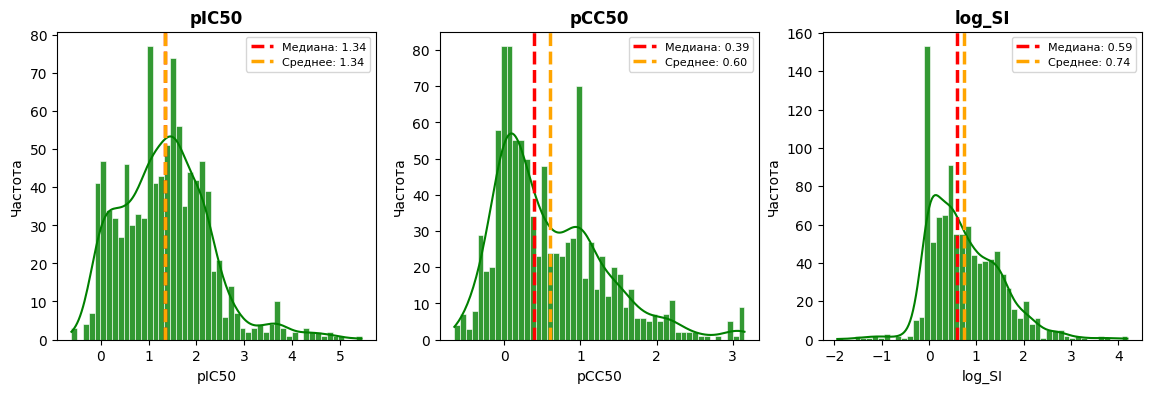

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(['pIC50', 'pCC50', 'log_SI']):

    ax1 = axes[i]
    sns.histplot(df[col], bins=50, kde=True, ax=ax1, color='green', edgecolor='white', alpha=0.8)

    # Линии медианы и среднего
    median_val = df[col].median()
    mean_val = df[col].mean()
    ax1.axvline(median_val, color='red', linestyle='--', linewidth=2.5, label=f'Медиана: {median_val:.2f}')
    ax1.axvline(mean_val, color='orange', linestyle='--', linewidth=2.5, label=f'Среднее: {mean_val:.2f}')

    ax1.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Частота')
    ax1.legend(fontsize=8)

### Результат обработки данных:

1. **Удалён столбец-идентификатор** `Unnamed: 0` — как неинформативный признак.
2. **Удалены 3 строки с пропусками** — все пропуски находились в одних и тех же записях, что составило менее 0.3% данных.
3. **Созданы лог-трансформации целевых переменных**:
   - `pIC50 = -log10(IC50/1000)` — стандарт хемоинформатики
   - `pCC50 = -log10(CC50/1000)` — аналогично IC50
   - `log_SI = log10(SI)` — для приведения к нормальному распределению

**Результат:** датасет очищен от неинформативных признаков и пропусков. Целевые переменные трансформированы и готовы к использованию в регрессионных моделях. Все выбросы сохранены.

## Корреляционный анализ

####Тепловая карта

In [52]:
# Целевые переменные
target_cols = ['IC50, mM', 'CC50, mM', 'SI']
log_targets = ['pIC50', 'pCC50', 'log_SI']

# Признаки (все столбцы, кроме целевых)
exclude_cols = target_cols + log_targets
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Признаков для анализа: {len(feature_cols)}")

# Матрица корреляции
corr_matrix = df[feature_cols + log_targets].corr()

Признаков для анализа: 210


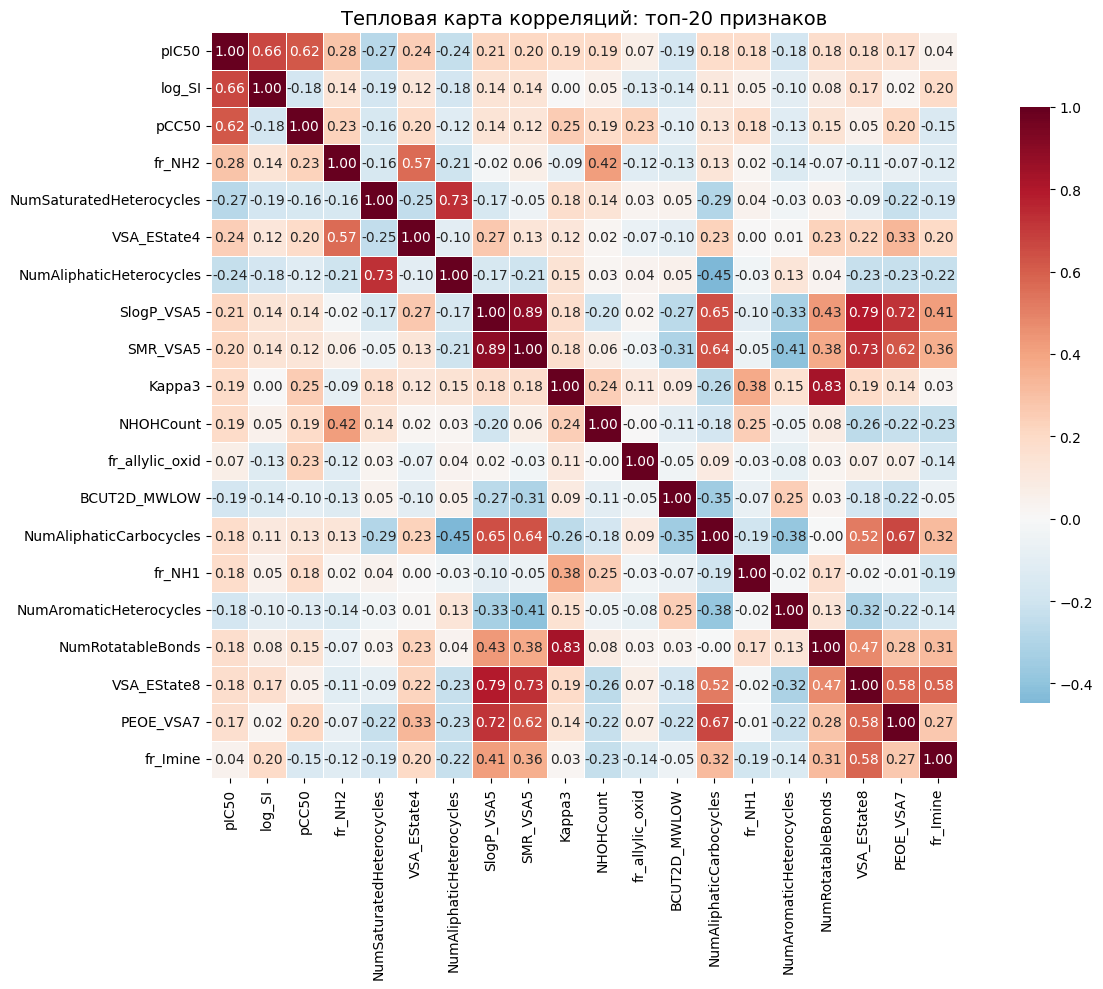

In [53]:
# Топ-20 признаков по суммарной корреляции с целевыми переменными
target_corr = corr_matrix[log_targets].abs().sum(axis=1)
top_features = target_corr.sort_values(ascending=False).head(20).index.tolist()

# Визуализация
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix.loc[top_features, top_features],
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Тепловая карта корреляций: топ-20 признаков', fontsize=14)
plt.tight_layout()
plt.show()

#### Топ-10 корреляций


In [54]:
# Корреляции с целевой переменной pIC50

corr_pIC50 = corr_matrix['pIC50'].drop(log_targets, errors='ignore').sort_values(ascending=False).dropna()
corr_pIC50

fr_NH2                      0.284640
VSA_EState4                 0.244084
SlogP_VSA5                  0.214853
SMR_VSA5                    0.204182
Kappa3                      0.191037
                              ...   
BCUT2D_CHGLO               -0.157304
NumAromaticHeterocycles    -0.178282
BCUT2D_MWLOW               -0.185726
NumAliphaticHeterocycles   -0.237885
NumSaturatedHeterocycles   -0.273176
Name: pIC50, Length: 192, dtype: float64

In [55]:
# Корреляции с целевой переменной 'pCC50'

corr_pCC50 = corr_matrix['pCC50'].drop(log_targets, errors='ignore').sort_values(ascending=False).dropna()
corr_pCC50

Kappa3                      0.249197
fr_NH2                      0.231687
fr_allylic_oxid             0.225293
EState_VSA2                 0.210757
PEOE_VSA7                   0.203986
                              ...   
FpDensityMorgan1           -0.143762
fr_Imine                   -0.148561
FpDensityMorgan2           -0.149975
NumSaturatedHeterocycles   -0.161014
BCUT2D_CHGLO               -0.162707
Name: pCC50, Length: 192, dtype: float64

In [56]:
# Корреляции с целевой переменной 'log_SI'

corr_log_SI = corr_matrix['log_SI'].drop(log_targets, errors='ignore').sort_values(ascending=False).dropna()
corr_log_SI

FractionCSP3                0.199683
fr_Imine                    0.195989
VSA_EState8                 0.172861
HallKierAlpha               0.161889
SlogP_VSA5                  0.139667
                              ...   
VSA_EState6                -0.171042
NumAliphaticHeterocycles   -0.183538
SlogP_VSA6                 -0.185944
NumSaturatedHeterocycles   -0.187970
SMR_VSA7                   -0.196915
Name: log_SI, Length: 192, dtype: float64

#### Мультиколлениарность

In [57]:
# Поиск пар с высокой корреляцией
high_corr_pairs = []
threshold = 0.9

for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        f1, f2 = feature_cols[i], feature_cols[j]
        corr_val = corr_matrix.loc[f1, f2]
        if abs(corr_val) > threshold:
            high_corr_pairs.append((f1, f2, corr_val))

print(f"Найдено пар с |r| > {threshold}: {len(high_corr_pairs)}")

Найдено пар с |r| > 0.9: 154


In [58]:
pd.DataFrame(high_corr_pairs)

,0,1,2
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
1,MolWt,HeavyAtomMolWt,0.996876
2,MolWt,ExactMolWt,0.999999
3,MolWt,NumValenceElectrons,0.981401
4,MolWt,BertzCT,0.903551
...,...,...,...
149,fr_Ar_OH,fr_phenol_noOrthoHbond,0.990790
150,fr_COO,fr_COO2,1.000000
151,fr_C_O,fr_C_O_noCOO,0.974924
152,fr_nitro_arom,fr_nitro_arom_nonortho,0.956942


Обнаружено **154 пары признаков с корреляцией выше 0.95** — это классический случай мультиколлинеарности, характерный для молекулярных дескрипторов.

Такие дублирующие признаки перегружают модели, вызывают переобучение и делают их нестабильными, особенно для линейных алгоритмов и нейросетей. Поэтому дублирующие признаки будут удалены: из каждой пары с `|r| > 0.95` оставляем один.

In [59]:
# 3. Определяем признаки для удаления (верхний треугольник corr matrix)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

df_cleaned = df.drop(columns=to_drop)

print(f"Удалено признаков: {len(to_drop)}")
print(f"Осталось признаков: {len(feature_cols) - len(to_drop)}")

Удалено признаков: 45
Осталось признаков: 165


In [60]:
df_cleaned

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumRadicalElectrons,...,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,pIC50,pCC50,log_SI
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0,...,0,0,0,0,0,3,0,2.204859,0.755766,1.449093
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0,...,0,0,0,0,0,3,0,3.112478,2.267380,0.845098
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0,...,0,0,0,0,0,3,0,0.650123,0.792790,-0.142668
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0,...,0,0,0,0,0,4,0,2.768117,0.967157,1.800960
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0,...,0,0,0,0,0,0,0,0.970083,0.856139,0.113943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,31.000104,34.999650,1.129017,12.934891,0.048029,-0.476142,0.382752,49.133333,414.542,0,...,0,0,0,0,0,0,0,1.508637,1.455936,0.052701
997,31.999934,33.999415,1.062484,13.635345,0.030329,-0.699355,0.369425,44.542857,485.621,0,...,0,0,0,0,0,0,0,1.494851,1.468529,0.026322
998,30.999883,33.999458,1.096761,13.991690,0.026535,-0.650790,0.284923,41.973684,545.742,0,...,0,0,0,0,0,0,0,1.508640,1.468528,0.040112
999,31.998959,32.999644,1.031272,13.830180,0.146522,-1.408652,0.381559,39.000000,522.635,0,...,0,0,0,0,0,0,0,1.494864,1.481491,0.013373


In [61]:
#df_cleaned.to_csv('df_cleaned.csv', index=False)

### Вывод по корреляционному анализу

В ходе анализа выявлены молекулярные дескрипторы, имеющие выраженную линейную связь с целевыми переменными(`pIC50`, `pCC50`, `log_SI`).

Основная проблема — **высокая мультиколлинеарность**: обнаружено 154 пары признаков с корреляцией > 0.9, что характерно для молекулярных дескрипторов. Для решения этой проблемы удалены высококоррелирующие признаки (порог > 0.95), в результате чего количество признаков сокращено с 210 до 165.

**Итог:** Датасет очищен от дублирующей информации и готов к масштабированию и построению моделей машинного обучения.